In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

In [2]:
import sys
sys.path.append("../modules")

import utils
import TwoLayers.sampling as sampling
import TwoLayers.langevin as langevin

In [3]:
MOutput = 1
MInput = 50
NSamples = int(1e6)

np.random.seed(42)

sigma_OI = 5
A_OI = sigma_OI * np.random.randn(MOutput, MInput)
g_OI = 5

A_output = np.eye((MOutput))
Sigma_output = scipy.linalg.solve_continuous_lyapunov(A_output, 2*np.eye(MOutput))

sigma_input = 0.5
A_input = np.random.randn(MInput, MInput)*sigma_input/np.sqrt(MInput)
A_input[np.diag_indices(MInput)] = 1
Sigma_input = scipy.linalg.solve_continuous_lyapunov(A_input, 2*np.eye(MInput))

input_samples_NS_s05, output_samples_NS_s05 = sampling.sample_nonlinearsum(NSamples, Sigma_input, Sigma_output, A_output, A_OI, g_OI)
input_samples_INT_s05, output_samples_INT_s05 = sampling.sample_integrated(NSamples, Sigma_input, Sigma_output, A_output, A_OI, g_OI)

sigma_input = 0.9
A_input = np.random.randn(MInput, MInput)*sigma_input/np.sqrt(MInput)
A_input[np.diag_indices(MInput)] = 1
Sigma_input = scipy.linalg.solve_continuous_lyapunov(A_input, 2*np.eye(MInput))

input_samples_NS_s09, output_samples_NS_s09 = sampling.sample_nonlinearsum(NSamples, Sigma_input, Sigma_output, A_output, A_OI, g_OI)
input_samples_INT_s09, output_samples_INT_s09 = sampling.sample_integrated(NSamples, Sigma_input, Sigma_output, A_output, A_OI, g_OI)

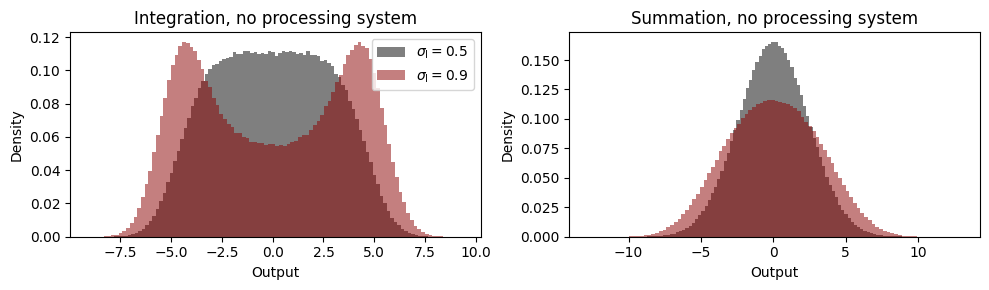

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(output_samples_INT_s05[0], bins=100, color='black', alpha=0.5, density=True, label = r"$\sigma_{\rm I} = 0.5$")
ax[0].hist(output_samples_INT_s09[0], bins=100, color='darkred', alpha=0.5, density=True, label = r"$\sigma_{\rm I} = 0.9$")
ax[0].set_xlabel("Output")
ax[0].set_ylabel("Density")
ax[0].set_title("Integration, no processing system")
ax[0].legend()

ax[1].hist(output_samples_NS_s05[0], bins=100, color='black', alpha=0.5, density=True)
ax[1].hist(output_samples_NS_s09[0], bins=100, color='darkred', alpha=0.5, density=True)
ax[1].set_xlabel("Output")
ax[1].set_ylabel("Density")
ax[1].set_title("Summation, no processing system")
plt.tight_layout()

plt.show()

In [12]:
MI_IO_INT_s05 = utils.get_MI_1D_output(output_samples_INT_s05[0], Sigma_output[0,0])
MI_IO_INT_s09 = utils.get_MI_1D_output(output_samples_INT_s09[0], Sigma_output[0,0])

MI_IO_NS_s05 = utils.get_MI_1D_output(output_samples_NS_s05[0], Sigma_output[0,0])
MI_IO_NS_s09 = utils.get_MI_1D_output(output_samples_NS_s09[0], Sigma_output[0,0])

print(f"Input-output mutual information (Integration, sigma_I = 0.5): {MI_IO_INT_s05}")
print(f"Input-output mutual information (Summation, sigma_I = 0.5): {MI_IO_NS_s05}")
print()
print(f"Input-output mutual information (Integration, sigma_I = 0.9): {MI_IO_INT_s09}")
print(f"Input-output mutual information (Summation, sigma_I = 0.9): {MI_IO_NS_s09}")

Input-output mutual information (Integration, sigma_I = 0.5): 1.4432873407824673
Input-output mutual information (Summation, sigma_I = 0.5): 1.2662564536577472

Input-output mutual information (Integration, sigma_I = 0.9): 1.655259399839193
Input-output mutual information (Summation, sigma_I = 0.9): 1.6481123250276486


In [13]:
NSteps = int(1e6)
dt = 1e-2
tau_input = 1
tau_output = 1e-1

x_input_NS, x_output_NS = langevin.simulate_nonlinearsum(NSteps, dt, tau_input, tau_output, A_input, A_output, A_OI, g_OI)
x_input_INT, x_output_INT = langevin.simulate_integrated(NSteps, dt, tau_input, tau_output, A_input, A_output, A_OI, g_OI)

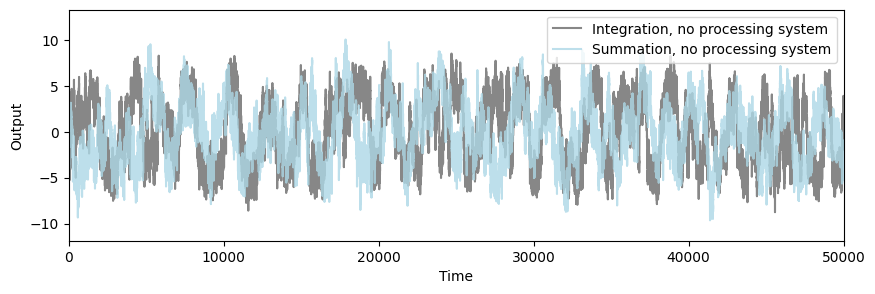

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

ax.plot(x_output_INT, color='dimgray', alpha=0.8, label="Integration, no processing system")
ax.plot(x_output_NS, color='lightblue', alpha=0.8, label="Summation, no processing system")

ax.set_xlim(0, 50000)

ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend(loc='upper right')
plt.show()

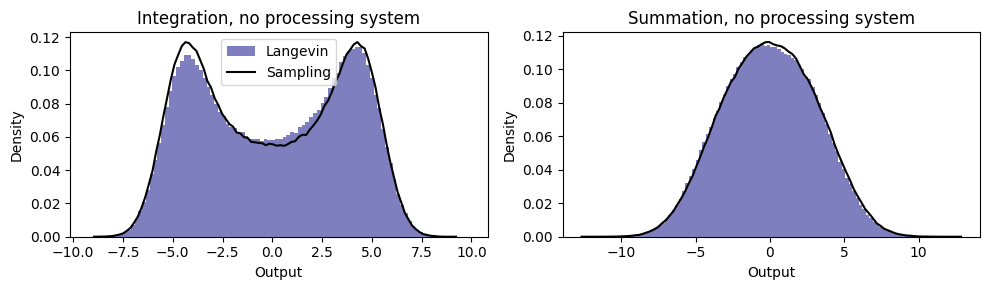

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(x_output_INT, bins=100, color='navy', alpha=0.5, density=True, label = "Langevin")
xtemp, ytemp = np.histogram(output_samples_INT_s09, bins=100, density=True)
ax[0].plot(0.5*(ytemp[1:]+ytemp[:-1]), xtemp, color='k', label="Sampling")

ax[0].set_xlabel("Output")
ax[0].set_ylabel("Density")
ax[0].set_title("Integration, no processing system")
ax[0].legend()

ax[1].hist(x_output_NS, bins=100, color='navy', alpha=0.5, density=True)
xtemp, ytemp = np.histogram(output_samples_NS_s09, bins=100, density=True)
ax[1].plot(0.5*(ytemp[1:]+ytemp[:-1]), xtemp, color='k')

ax[1].set_xlabel("Output")
ax[1].set_ylabel("Density")
ax[1].set_title("Summation, no processing system")

plt.tight_layout()
plt.show()